## Shah hetvi Ileshkumar

### Social Network Activity Clustering 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")

In [3]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
df.tail()

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [6]:
df.describe

<bound method NDFrame.describe of      Age  EstimatedSalary  Purchased
0     19            19000          0
1     35            20000          0
2     26            43000          0
3     27            57000          0
4     19            76000          0
..   ...              ...        ...
395   46            41000          1
396   51            23000          1
397   50            20000          1
398   36            33000          0
399   49            36000          1

[400 rows x 3 columns]>

In [7]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [8]:
X = df[['Age','EstimatedSalary']]

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
wcss = []

In [11]:
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


In [12]:
wcss

[800.0000000000001,
 518.0862059633738,
 323.87195929760384,
 248.2546506674493,
 193.26970176488132,
 133.7644551553738,
 113.14783637033567,
 102.31877445562989,
 89.19792098477802,
 82.03057078037]

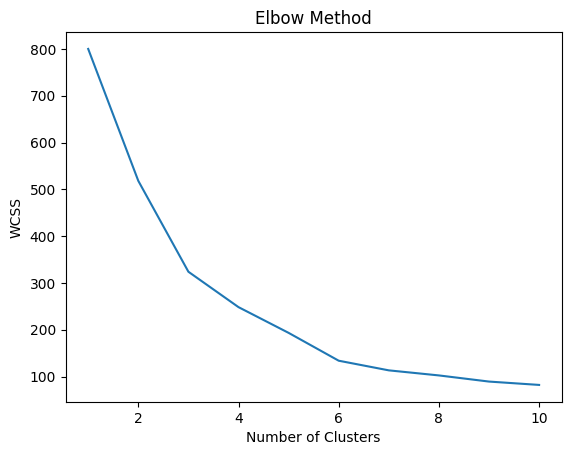

In [13]:
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

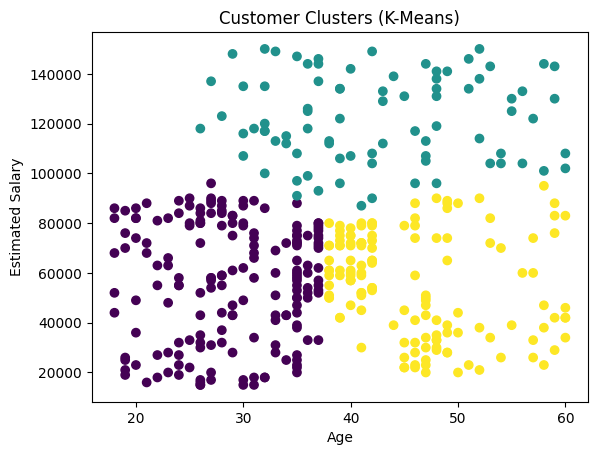

In [15]:
plt.scatter(df['Age'], df['EstimatedSalary'], c=df['Cluster'])
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Customer Clusters (K-Means)")
plt.show()

In [16]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [17]:
linked = linkage(X_scaled, method='ward')

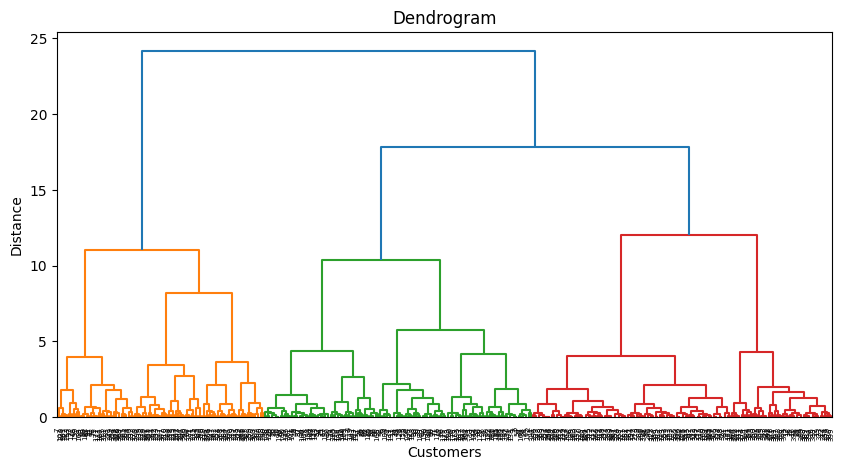

In [18]:
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [19]:
from sklearn.cluster import AgglomerativeClustering

In [20]:
model = AgglomerativeClustering(n_clusters=3)
df['Cluster2'] = model.fit_predict(X_scaled)

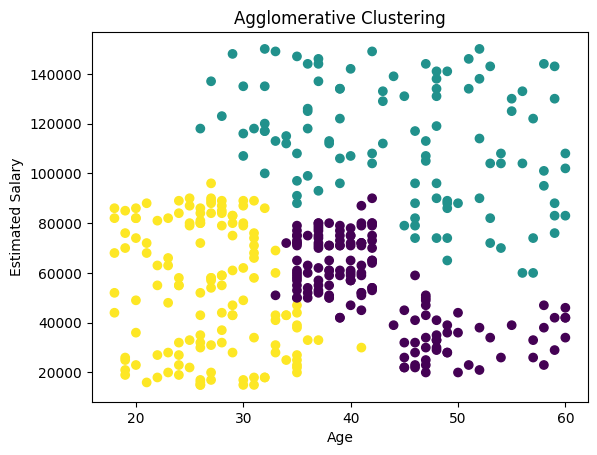

In [21]:
plt.scatter(df['Age'], df['EstimatedSalary'], c=df['Cluster2'])
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Agglomerative Clustering")
plt.show()